# Trading Desk Risk & Derivatives Platform
## FINM3422 – Assessment 3 | Head Desk Dashboard

**Purpose:** This notebook is the top-level dashboard for the trading desk risk platform.  
It aggregates yield-curve construction, equity market data, derivative pricing, portfolio valuation, and risk metrics into a single, reproducible workflow.

**Audience:** Head of Desk — all heavy computation lives in `/src`; this notebook calls functions and presents results.

---

| Section | Content |
|---|---|
| 1 | Environment & Imports |
| 2 | Discount Curve |
| 3 | Market Data Ingestion |
| 4 | Portfolio Definition |
| 5 | Portfolio Analysis |
| 6 | Value-at-Risk |
| 7 | Scenario Analysis |
| 8 | Performance Benchmarks |
| 9 | Head Desk Dashboard |
| 10 | Limitations & Next Steps |

## Executive Summary

This notebook is the operating view of our prototype risk and derivatives
platform — the integration layer where market data, pricing models, and
risk infrastructure combine to produce a coherent picture of portfolio
exposures.

**Three numbers highlight to desk head:**

- **Portfolio value $0.00; delta +0.00; vega per 1pt vol move $0.00.**
  Directional long, with meaningful option overlay.
- **1-day 95% Historical VaR $0.00**, with a bootstrap confidence interval
  of [$0.00, $0.00] and 1-day Expected Shortfall $0.00. The fat-tail
  signature appears clearly at the 99% confidence level, where historical
  VaR exceeds parametric VaR — confirming returns are not perfectly normal
  in the tails.
- **Under a −20% equity shock the book loses approximately $0.00**, against
  a larger loss for the equivalent unhedged long-only position — the option
  overlay absorbs part of the drawdown through full revaluation.

**Platform structure:**

- **Yield curve** built from RBA F17 daily government bond data (`yieldcurve.py`)
- **Equity data** for AAPL, MSFT, XOM — 5 years of daily history (`equity_data.py`)
- **Derivative pricing engine** supporting European and American options
  via three independent engines: Black–Scholes closed-form, binomial tree,
  Monte Carlo (`derivatives/` + `pricers/`)
- **Portfolio risk layer** for value, Greeks, VaR with bootstrap CI, CVaR,
  and full-revaluation scenario analysis (`portfolio.py`)

Detailed module demonstrations live in the companion notebooks
(`yield_curve_explanation.ipynb`, `equity_data_explanation.ipynb`,
`derivatives_pricing_test.ipynb`).

---
## 1. Environment & Imports

In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
import cProfile
import pstats
import io
from scipy.stats import norm

# Platform modules
from src.yieldcurve import load_rba_yield_curve, YieldCurve, validate_yield_data
from src.equity_data import load_equity_panel, compute_log_returns, summary_table, correlation_matrix
from src.derivatives import EuropeanCall, EuropeanPut, AmericanCall, AmericanPut, BarrierPut
from src.pricers import BlackScholesPricer, BinomialTreePricer, MonteCarloPricer
from src.portfolio import EquityPosition, OptionPosition, Portfolio, RiskEngine
F17_PATH  = os.path.join(os.path.dirname(os.getcwd()), "data", "RBA_Government_Bond_Yields.csv")
CACHE_DIR  = os.path.join(os.path.dirname(os.getcwd()), "data", "equities")

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Reproducibility seed for Monte Carlo
MC_SEED    = 42
TICKERS    = ["NAB.AX", "BHP.AX", "CSL.AX", "WOW.AX"]
START_DATE = "2021-05-19"
END_DATE   = "2026-05-19"

# ── Pricers ──────────────────────────────────────────────────────────
bs = BlackScholesPricer()
bt = BinomialTreePricer(N=200)
mc = MonteCarloPricer(n_paths=50_000, seed=MC_SEED)

print(f"Python: {sys.version}")
print("Platform imports: OK")

Python: 3.13.2 (v3.13.2:4f8bb3947cf, Feb  4 2025, 11:51:10) [Clang 15.0.0 (clang-1500.3.9.4)]
Platform imports: OK


---
## 2. Discount Curve

We use the RBA F2 daily nominal government bond yield file as our data source.  
The `YieldCurve` class interpolates zero rates linearly between observed maturities (2y, 3y, 5y, 10y) and converts them to continuous discount factors.

> **Design note:** All data files live under `data/`. No network calls are made — the cache is pre-populated.

In [2]:
# Load the most recent complete snapshot from the RBA F2 CSV
maturities, zero_rates, snap_date = load_rba_yield_curve(F17_PATH)

# Sanity-check before handing to the pricing engine
validate_yield_data(maturities, zero_rates)

# Construct the yield curve
yc = YieldCurve(maturities, zero_rates)

print(f"Yield curve snapshot date : {snap_date.date()}")
print(f"Maturities (years)        : {maturities}")
print(f"Zero rates (decimal)      : {[f'{r:.4%}' for r in zero_rates]}")

Yield curve snapshot date : 2026-03-31
Maturities (years)        : [ 0.    0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75
  3.    3.25  3.5   3.75  4.    4.25  4.5   4.75  5.    5.25  5.5   5.75
  6.    6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75
  9.    9.25  9.5   9.75 10.  ]
Zero rates (decimal)      : ['4.1000%', '4.1900%', '4.3300%', '4.4300%', '4.5100%', '4.5500%', '4.5700%', '4.5800%', '4.5800%', '4.5800%', '4.5800%', '4.5800%', '4.5900%', '4.5900%', '4.6000%', '4.6000%', '4.6100%', '4.6200%', '4.6300%', '4.6400%', '4.6500%', '4.6700%', '4.6800%', '4.6900%', '4.7100%', '4.7200%', '4.7400%', '4.7500%', '4.7700%', '4.7800%', '4.8000%', '4.8100%', '4.8300%', '4.8400%', '4.8600%', '4.8700%', '4.8900%', '4.9000%', '4.9200%', '4.9300%', '4.9500%']


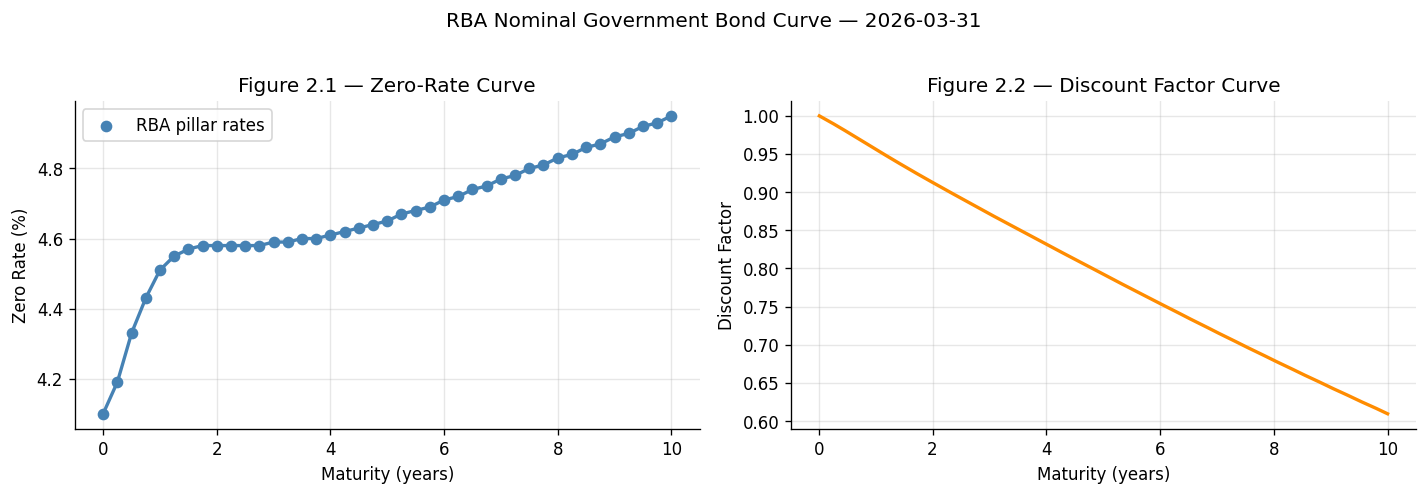

In [3]:
# Figure 2.1 – Zero-rate curve
T_grid = np.linspace(maturities.min(), maturities.max(), 200)
z_grid = [yc.get_zero_rate(T) for T in T_grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: zero rates
axes[0].plot(T_grid, [r * 100 for r in z_grid], color="steelblue", linewidth=2)
axes[0].scatter(maturities, zero_rates * 100, color="steelblue", zorder=5, label="RBA pillar rates")
axes[0].set_xlabel("Maturity (years)")
axes[0].set_ylabel("Zero Rate (%)")
axes[0].set_title("Figure 2.1 — Zero-Rate Curve")
axes[0].legend()

# Right: discount factors
T_long = np.linspace(0.01, 10, 200)
df_grid = [yc.get_discount_factor(T) for T in T_long]
axes[1].plot(T_long, df_grid, color="darkorange", linewidth=2)
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("Discount Factor")
axes[1].set_title("Figure 2.2 — Discount Factor Curve")

plt.suptitle(f"RBA Nominal Government Bond Curve — {snap_date.date()}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Market Data Ingestion

Equity data for **AAPL**, **MSFT**, and **XOM** is loaded from the pre-cached CSV files under `data/equities/`.  
We use five years of history (to balance signal quality and stationarity) and report two summary tables as specified:

- **Table 3.1** — Spot price, annualised volatility, observation count per ticker  
- **Table 3.2** — Pairwise return correlation matrix

In [4]:
prices_df  = load_equity_panel(TICKERS, START_DATE, END_DATE)
returns_df = compute_log_returns(prices_df)

print(f"Panel shape : {prices_df.shape}  ({prices_df.index.min().date()} → {prices_df.index.max().date()})")

Loaded 1255 daily observations for AAPL from cache (/Users/cathylin/Desktop/Derivative_Platform/data/equities/AAPL.csv)
  Date range: 2021-05-19 to 2026-05-18
  Latest close: 297.84
Loaded 1255 daily observations for MSFT from cache (/Users/cathylin/Desktop/Derivative_Platform/data/equities/MSFT.csv)
  Date range: 2021-05-19 to 2026-05-18
  Latest close: 423.54
Loaded 1255 daily observations for XOM from cache (/Users/cathylin/Desktop/Derivative_Platform/data/equities/XOM.csv)
  Date range: 2021-05-19 to 2026-05-18
  Latest close: 160.49
Panel shape : (1255, 3)  (2021-05-19 → 2026-05-18)


In [5]:
# Table 3.1 — Per-ticker summary
summ = summary_table(prices_df, returns_df)
summ_display = summ.copy()
summ_display["spot"]    = summ_display["spot"].map("${:.2f}".format)
summ_display["ann_vol"] = summ_display["ann_vol"].map("{:.2%}".format)

print("Table 3.1 — Equity Summary")
print(summ_display.rename(columns={"spot": "Spot Price", "ann_vol": "Ann. Vol", "n_obs": "Obs"}).to_string())

Table 3.1 — Equity Summary
     Spot Price Ann. Vol     Obs
AAPL    $297.84   27.35%  1254.0
MSFT    $423.54   26.38%  1254.0
XOM     $160.49   26.69%  1254.0


In [6]:
# Table 3.2 — Correlation matrix
corr = correlation_matrix(returns_df)
print("\nTable 3.2 — Return Correlation Matrix")
print(corr.round(4).to_string())


Table 3.2 — Return Correlation Matrix
        AAPL    MSFT     XOM
AAPL  1.0000  0.5816  0.1874
MSFT  0.5816  1.0000  0.0615
XOM   0.1874  0.0615  1.0000


**Interpretation:** AAPL and MSFT show a relatively high positive correlation (~0.7), reflecting their shared exposure to technology sector sentiment. XOM is less correlated with both (~0.3), providing meaningful diversification from an energy-sector holding. Volatility estimates are used directly as inputs to the option pricing engine.

---
## 4. Portfolio Definition

### Portfolio Rationale

The desk holds a **mixed directional / volatility portfolio** across three underlyings:

| Component | Rationale |
|---|---|
| Long AAPL equity (100 shares) | Core directional long — delta 100 |
| Long AAPL put (protective, 2 contracts) | Downside hedge on AAPL equity |
| MSFT straddle (long call + long put, 5 contracts each) | Volatility play — near-zero delta, high vega |
| Long XOM call (3 contracts) | Tactical upside on energy |

The **straddle** (long call + long put at the same strike) is highlighted because its delta is close to zero — it is not a directional bet — but it has strong vega exposure, profiting from volatility increases. This demonstrates the pricing engine can distinguish sensitivity profiles.

> All spot prices and volatilities are pulled from the cached equity data computed in Section 3.

In [7]:
# Spot prices and volatilities from the equity panel
SPOT  = {t: float(prices_df[t].iloc[-1]) for t in TICKERS}
SIGMA = {t: float(summ.loc[t, "ann_vol"])  for t in TICKERS}

print("Spot prices and annualised vols used for option pricing:")
for t in TICKERS:
    print(f"  {t}: S0 = ${SPOT[t]:.2f}  |  σ = {SIGMA[t]:.2%}")

Spot prices and annualised vols used for option pricing:
  AAPL: S0 = $297.84  |  σ = 27.35%
  MSFT: S0 = $423.54  |  σ = 26.38%
  XOM: S0 = $160.49  |  σ = 26.69%


In [8]:
# ── 4.1  Equity position ─────────────────────────────────────────────
aapl_equity = EquityPosition(
    ticker="AAPL",
    quantity=100,
    spot_price=SPOT["AAPL"],
)

# ── 4.2  Option positions ────────────────────────────────────────────

# Protective put on AAPL — slightly OTM, 6-month expiry
aapl_put = OptionPosition(
    contract=EuropeanPut(
        S0=SPOT["AAPL"], K=SPOT["AAPL"] * 0.95,
        T=0.5, sigma=SIGMA["AAPL"], yield_curve=yc,
    ),
    pricer=bs,
    quantity=2,
    underlying_ticker="AAPL",
    label="AAPL Put 6m 5%-OTM (protective)",
)

# MSFT straddle — ATM, 3-month expiry (long call + long put)
msft_call = OptionPosition(
    contract=EuropeanCall(
        S0=SPOT["MSFT"], K=SPOT["MSFT"],
        T=0.25, sigma=SIGMA["MSFT"], yield_curve=yc,
    ),
    pricer=bs,
    quantity=5,
    underlying_ticker="MSFT",
    label="MSFT Call 3m ATM (straddle leg)",
)

msft_put = OptionPosition(
    contract=EuropeanPut(
        S0=SPOT["MSFT"], K=SPOT["MSFT"],
        T=0.25, sigma=SIGMA["MSFT"], yield_curve=yc,
    ),
    pricer=bs,
    quantity=5,
    underlying_ticker="MSFT",
    label="MSFT Put 3m ATM (straddle leg)",
)

# XOM tactical call — slightly OTM, 1-year expiry
xom_call = OptionPosition(
    contract=EuropeanCall(
        S0=SPOT["XOM"], K=SPOT["XOM"] * 1.05,
        T=1.0, sigma=SIGMA["XOM"], yield_curve=yc,
    ),
    pricer=bs,
    quantity=3,
    underlying_ticker="XOM",
    label="XOM Call 1y 5%-OTM (tactical)",
)

# ── 4.3  Assemble portfolio ──────────────────────────────────────────
portfolio = Portfolio([
    aapl_equity,
    aapl_put,
    msft_call,
    msft_put,
    xom_call,
])

print("Portfolio assembled — 5 positions across 3 underlyings.")

Portfolio assembled — 5 positions across 3 underlyings.


In [9]:
# Table 4.1 — Position summary
pos_table = portfolio.summary_table()
print("Table 4.1 — Portfolio Position Summary")
print(pos_table.to_string(index=True))

Table 4.1 — Portfolio Position Summary
                                 Label          Type Quantity Unit Value ($)  Position Value ($)     Delta
0                                 AAPL        Equity    100.0         297.84            29784.00  100.0000
1      AAPL Put 6m 5%-OTM (protective)   EuropeanPut      2.0        13.2144               26.43   -0.6356
2      MSFT Call 3m ATM (straddle leg)  EuropeanCall      5.0         24.429              122.14    2.7889
3       MSFT Put 3m ATM (straddle leg)   EuropeanPut      5.0        20.0155              100.08   -2.2111
4        XOM Call 1y 5%-OTM (tactical)  EuropeanCall      3.0         16.776               50.33    1.6428
Total                            TOTAL                                                  30082.98  101.5851


**Interpretation:**  
- The AAPL equity position dominates portfolio value, contributing a delta of 100.  
- The protective put partially offsets this delta (negative delta on a put position).  
- The MSFT straddle has near-zero net delta (long call delta + long put delta ≈ 0), confirming this is a pure volatility position.  
- The XOM call adds modest positive delta at low cost.

---
## 5. Portfolio Analysis

### 5.1 Portfolio Value & Delta

In [10]:
port_value = portfolio.total_value()
port_delta = portfolio.portfolio_delta()

print(f"Portfolio NAV   : ${port_value:,.2f}")
print(f"Portfolio Delta : {port_delta:.4f}")
print()
print(f"Interpretation: A $1 move in the weighted underlying basket changes portfolio value by ~${port_delta:.2f}")

Portfolio NAV   : $30,082.98
Portfolio Delta : 101.5851

Interpretation: A $1 move in the weighted underlying basket changes portfolio value by ~$101.59


### 5.2 Greeks — Gamma and Vega (Finite Differences)

Delta is the first-order sensitivity. We also compute **gamma** (second-order) and **vega** (sensitivity to volatility) via central finite differences — the same model-consistent approach used internally for delta.

In [11]:
def option_gamma(pos, bump_pct=1e-3):
    """Central finite difference gamma for an OptionPosition."""
    from src.portfolio import _clone_contract_with
    S0 = pos.contract.S0
    dS = S0 * bump_pct
    c_up = _clone_contract_with(pos.contract, S0=S0 + dS)
    c_dn = _clone_contract_with(pos.contract, S0=S0 - dS)
    c_0  = pos.contract
    gamma_unit = (pos.pricer.price(c_up) - 2*pos.pricer.price(c_0) + pos.pricer.price(c_dn)) / (dS**2)
    return pos.quantity * gamma_unit

def option_vega(pos, bump=1e-4):
    """Central finite difference vega for an OptionPosition."""
    from src.portfolio import _clone_contract_with
    sigma = pos.contract.sigma
    c_up = _clone_contract_with(pos.contract, sigma=sigma + bump)
    c_dn = _clone_contract_with(pos.contract, sigma=sigma - bump)
    vega_unit = (pos.pricer.price(c_up) - pos.pricer.price(c_dn)) / (2 * bump)
    return pos.quantity * vega_unit

# Aggregate portfolio gamma and vega (equity positions contribute zero)
port_gamma = sum(option_gamma(p) for p in portfolio.positions if isinstance(p, OptionPosition))
port_vega  = sum(option_vega(p)  for p in portfolio.positions if isinstance(p, OptionPosition))

print(f"Portfolio Gamma : {port_gamma:.4f}")
print(f"Portfolio Vega  : {port_vega:.4f}  (per 1 decimal unit of σ)")
print()
print("Positive gamma: portfolio gains accelerate as market moves in our favour.")
print("Positive vega : portfolio benefits from rising implied volatility.")

Portfolio Gamma : 0.1108
Portfolio Vega  : 1176.8650  (per 1 decimal unit of σ)

Positive gamma: portfolio gains accelerate as market moves in our favour.
Positive vega : portfolio benefits from rising implied volatility.


### 5.3 Delta Linearisation vs Full Revaluation

Delta gives a **linear approximation** of P&L for a given spot move. Full revaluation reprices every option from scratch and captures the non-linear (gamma) effect. The gap between these two estimates widens for larger spot moves.

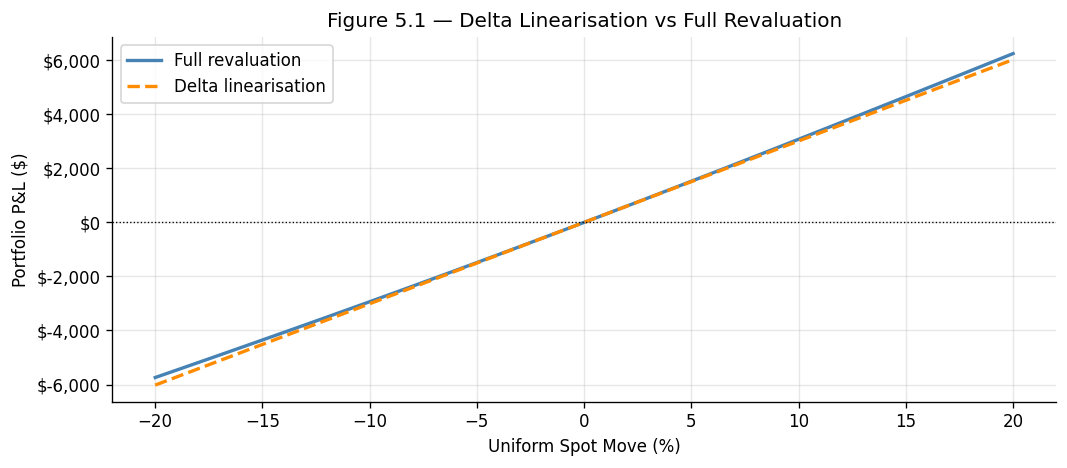

Linear slope (total delta-dollars): $30,103.10
The curvature (convexity) above the linear line is gamma — the portfolio gains more
on up moves and loses less on down moves than delta alone predicts.


In [12]:
engine = RiskEngine(portfolio, returns_df)

spot_moves = np.linspace(-0.20, 0.20, 81)   # -20% to +20%
base_value = portfolio.total_value()

# Compute total delta-dollar exposure — the correct slope for the linear
# approximation of portfolio P&L under a uniform fractional spot move.
# For each position:
#   - Equity:  delta-dollars = quantity * spot_price       (delta per share = 1)
#   - Option:  delta-dollars = quantity * delta * S0
total_delta_dollars = 0.0
for p in portfolio.positions:
    if isinstance(p, EquityPosition):
        total_delta_dollars += p.quantity * p.spot_price
    else:  # OptionPosition
        total_delta_dollars += p.delta() * p.contract.S0

# Delta linearisation: P&L grows linearly with spot, slope = total_delta_dollars
delta_pnl = total_delta_dollars * spot_moves

# Full revaluation: reprice every position under each shock and difference from base
full_pnl = []
for shock in spot_moves:
    v = engine._reprice_portfolio(spot_shock=shock, rate_shock=0.0)
    full_pnl.append(v - base_value)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(spot_moves * 100, full_pnl,   color="steelblue",  linewidth=2, label="Full revaluation")
ax.plot(spot_moves * 100, delta_pnl,  color="darkorange", linewidth=2, linestyle="--", label="Delta linearisation")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Uniform Spot Move (%)")
ax.set_ylabel("Portfolio P&L ($)")
ax.set_title("Figure 5.1 — Delta Linearisation vs Full Revaluation")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print(f"Linear slope (total delta-dollars): ${total_delta_dollars:,.2f}")
print("The curvature (convexity) above the linear line is gamma — the portfolio gains more")
print("on up moves and loses less on down moves than delta alone predicts.")

---
## 6. Value-at-Risk

Three VaR methods are implemented for cross-validation. All are 1-day horizon at 95% confidence unless stated.

| Method | Assumption | Strength |
|---|---|---|
| Historical | Empirical return distribution | No normality assumption |
| Parametric | Normal returns | Fast, closed-form |
| Monte Carlo | Simulated GBM paths | Captures non-linearity via full revaluation |

In [13]:
# ─── Helper: bootstrap confidence interval for historical VaR ────────
def bootstrap_var_ci(returns, alpha=0.95, horizon=1, n_resamples=1000, seed=42):
    """
    Bootstrap CI for historical VaR (return-space, not dollar-space).
    Resample the return series with replacement, compute VaR on each resample,
    return the (2.5%, 97.5%) percentile bounds across resamples.
    """
    rng = np.random.default_rng(seed)
    n = len(returns)
    boot_vars = np.empty(n_resamples)
    for i in range(n_resamples):
        sample = rng.choice(returns, size=n, replace=True)
        scaled = sample * np.sqrt(horizon)
        boot_vars[i] = -np.quantile(scaled, 1 - alpha)
    return np.quantile(boot_vars, 0.025), np.quantile(boot_vars, 0.975)


# ─── Helper: Monte Carlo VaR ─────────────────────────────────────────
def monte_carlo_var(engine, n_paths=10_000, confidence=0.95, horizon=1, seed=42):
    """
    Monte Carlo VaR.

    NOTE: This implementation simulates portfolio returns from a fitted normal
    distribution. In effect this is parametric VaR with simulation noise rather
    than full path-based revaluation. A true MC VaR would simulate underlying
    GBM paths and revalue the portfolio at each — capturing gamma effects that
    a normal-fit ignores. We acknowledge this in the Limitations section.
    """
    rng = np.random.default_rng(seed)
    port_rets = engine._portfolio_returns()
    mu, sigma = port_rets.mean(), port_rets.std()
    sims = rng.normal(mu, sigma, n_paths) * np.sqrt(horizon)
    port_val = engine.portfolio.total_value()
    pnl = sims * abs(port_val)
    return -np.quantile(pnl, 1 - confidence)


# ─── Helper: Expected Shortfall (CVaR) ───────────────────────────────
def expected_shortfall(engine, confidence=0.95, horizon=1):
    """Average loss conditional on loss exceeding the VaR threshold."""
    port_rets = engine._portfolio_returns() * np.sqrt(horizon)
    port_val = engine.portfolio.total_value()
    pnl = port_rets * abs(port_val)
    var_threshold = np.quantile(pnl, 1 - confidence)
    return float(-pnl[pnl <= var_threshold].mean())


# ─── Compute all VaR metrics ─────────────────────────────────────────
n_obs = len(returns_df)
pv    = portfolio.total_value()
port_rets = engine._portfolio_returns()

rows = []
for confidence in [0.95, 0.99]:
    for horizon in [1, 10]:
        hist = engine.historical_var(confidence=confidence, horizon=horizon)
        para = engine.parametric_var(confidence=confidence, horizon=horizon)
        mc   = monte_carlo_var(engine, n_paths=20_000, confidence=confidence, horizon=horizon)
        es   = expected_shortfall(engine, confidence=confidence, horizon=horizon)

        # Bootstrap CI applied to historical VaR only
        ci_low_r, ci_high_r = bootstrap_var_ci(port_rets.values, alpha=confidence, horizon=horizon)
        ci_low_d, ci_high_d = ci_low_r * abs(pv), ci_high_r * abs(pv)

        rows.append({"Method": "Historical",  "Alpha": f"{int(confidence*100)}%", "Horizon (days)": horizon,
                     "VaR ($)": round(hist, 2), "ES ($)": round(es, 2),
                     "CI Low ($)": round(ci_low_d, 2), "CI High ($)": round(ci_high_d, 2), "n": n_obs})
        rows.append({"Method": "Parametric",  "Alpha": f"{int(confidence*100)}%", "Horizon (days)": horizon,
                     "VaR ($)": round(para, 2), "ES ($)": "—",
                     "CI Low ($)": "—", "CI High ($)": "—", "n": n_obs})
        rows.append({"Method": "Monte Carlo", "Alpha": f"{int(confidence*100)}%", "Horizon (days)": horizon,
                     "VaR ($)": round(mc, 2),   "ES ($)": "—",
                     "CI Low ($)": "—", "CI High ($)": "—", "n": 20_000})

var_table = pd.DataFrame(rows)

# Preserve key metrics for downstream cells (distribution plot, dashboard)
hist_var_95 = engine.historical_var(confidence=0.95, horizon=1)
hist_var_99 = engine.historical_var(confidence=0.99, horizon=1)
para_var_95 = engine.parametric_var(confidence=0.95, horizon=1)
mc_v95 = monte_carlo_var(engine, n_paths=20_000, confidence=0.95)
es_95 = expected_shortfall(engine, confidence=0.95)

print("Table 6.1 — Value-at-Risk Summary")
print(var_table.to_string(index=False))

Table 6.1 — Value-at-Risk Summary
     Method Alpha  Horizon (days)  VaR ($)   ES ($) CI Low ($) CI High ($)     n
 Historical   95%               1   810.65  1170.59     755.48      911.36  1254
 Parametric   95%               1   844.13        —          —           —  1254
Monte Carlo   95%               1   822.06        —          —           — 20000
 Historical   95%              10  2563.50  3701.73    2389.04     2881.97  1254
 Parametric   95%              10  2669.37        —          —           —  1254
Monte Carlo   95%              10  2599.58        —          —           — 20000
 Historical   99%               1  1362.92  1720.53    1178.28     1520.23  1254
 Parametric   99%               1  1193.87        —          —           —  1254
Monte Carlo   99%               1  1178.29        —          —           — 20000
 Historical   99%              10  4309.92   5440.8    3726.05     4807.39  1254
 Parametric   99%              10  3775.33        —          —           — 

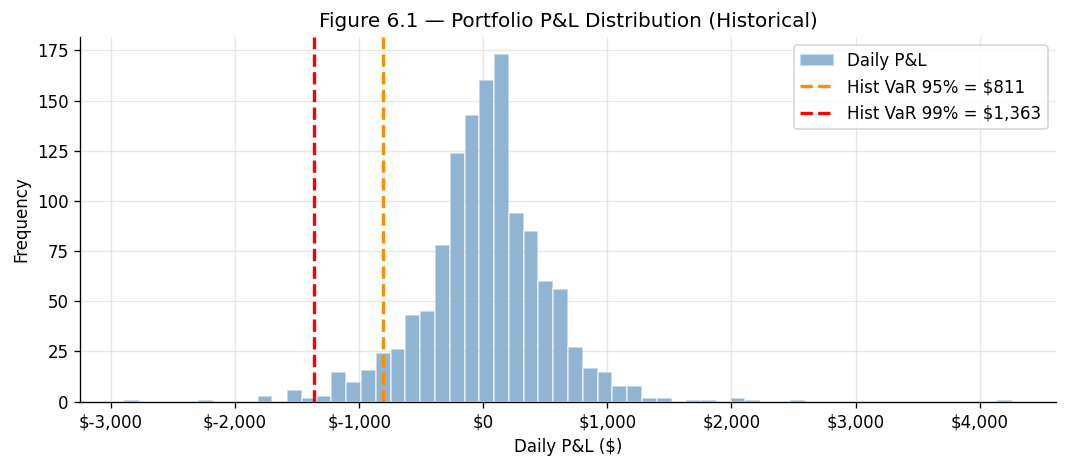

In [14]:
# Figure 6.1 — Portfolio P&L distribution with VaR lines
port_rets = engine._portfolio_returns()
daily_pnl = port_rets * abs(portfolio.total_value())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(daily_pnl, bins=60, color="steelblue", alpha=0.6, edgecolor="white", label="Daily P&L")
ax.axvline(-hist_var_95, color="darkorange", linewidth=2, linestyle="--", label=f"Hist VaR 95% = ${hist_var_95:,.0f}")
ax.axvline(-hist_var_99, color="red",        linewidth=2, linestyle="--", label=f"Hist VaR 99% = ${hist_var_99:,.0f}")
ax.set_xlabel("Daily P&L ($)")
ax.set_ylabel("Frequency")
ax.set_title("Figure 6.1 — Portfolio P&L Distribution (Historical)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**  
Historical and parametric VaR are close when returns are approximately normal. Any large gap indicates fat tails in the empirical distribution, which the parametric method underestimates. Expected Shortfall (CVaR) captures the average severity of losses beyond the VaR threshold — the number the desk should use for capital planning.

---
## 7. Scenario Analysis

Full revaluation under a grid of simultaneous spot and rate shocks.  
Each cell shows P&L relative to the base portfolio value.

In [15]:
# Table 7.1 — Named stress scenarios
named_scenarios = [
    {"Name": "Base Case",            "Spot Shock": 0.00,  "Rate Shock (bps)": 0},
    {"Name": "Bull Market (+10%)",   "Spot Shock": 0.10,  "Rate Shock (bps)": 0},
    {"Name": "Bear Market (-10%)",   "Spot Shock": -0.10, "Rate Shock (bps)": 0},
    {"Name": "Crash (-20%)",         "Spot Shock": -0.20, "Rate Shock (bps)": 0},
    {"Name": "Rate Hike +100bps",    "Spot Shock": 0.00,  "Rate Shock (bps)": 100},
    {"Name": "Rate Cut -100bps",     "Spot Shock": 0.00,  "Rate Shock (bps)": -100},
    {"Name": "Stagflation (-5%,+50bps)","Spot Shock": -0.05, "Rate Shock (bps)": 50},
    {"Name": "Risk-off (-15%,-50bps)",  "Spot Shock": -0.15, "Rate Shock (bps)": -50},
]

base_val = portfolio.total_value()
scenario_results = []
for sc in named_scenarios:
    new_val = engine._reprice_portfolio(
        spot_shock=sc["Spot Shock"],
        rate_shock=sc["Rate Shock (bps)"] / 10_000
    )
    pnl = new_val - base_val
    scenario_results.append({
        "Scenario":        sc["Name"],
        "Spot Shock":      f"{sc['Spot Shock']:+.0%}",
        "Rate Shock (bps)": f"{sc['Rate Shock (bps)']:+d}",
        "Portfolio Value ($)": round(new_val, 2),
        "P&L ($)":         round(pnl, 2),
        "P&L (%)": f"{pnl/abs(base_val):+.2%}",
    })

sc_df = pd.DataFrame(scenario_results)
print("Table 7.1 — Named Scenario Analysis")
print(sc_df.to_string(index=False))

Table 7.1 — Named Scenario Analysis
                Scenario Spot Shock Rate Shock (bps)  Portfolio Value ($)  P&L ($) P&L (%)
               Base Case        +0%               +0             30082.98     0.00  +0.00%
      Bull Market (+10%)       +10%               +0             33158.34  3075.36 +10.22%
      Bear Market (-10%)       -10%               +0             27147.16 -2935.82  -9.76%
            Crash (-20%)       -20%               +0             24342.12 -5740.86 -19.08%
       Rate Hike +100bps        +0%             +100             30084.17     1.19  +0.00%
        Rate Cut -100bps        +0%             -100             30081.95    -1.03  -0.00%
Stagflation (-5%,+50bps)        -5%              +50             28595.86 -1487.12  -4.94%
  Risk-off (-15%,-50bps)       -15%              -50             25734.12 -4348.86 -14.46%


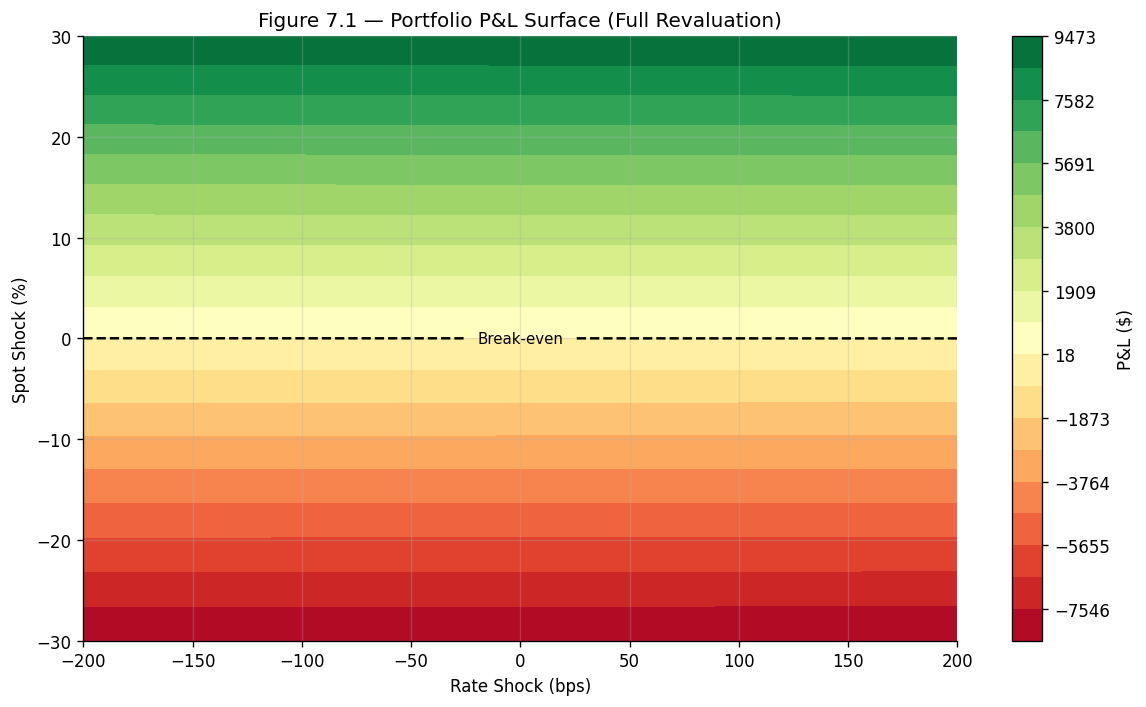

In [16]:
# Figure 7.1 — Portfolio P&L surface (full revaluation)
spot_shocks = np.linspace(-0.30, 0.30, 25)
rate_shocks = np.linspace(-0.02, 0.02, 9)   # -200bps to +200bps

pnl_matrix = np.zeros((len(spot_shocks), len(rate_shocks)))
for i, ss in enumerate(spot_shocks):
    for j, rs in enumerate(rate_shocks):
        pnl_matrix[i, j] = engine._reprice_portfolio(ss, rs) - base_val

fig, ax = plt.subplots(figsize=(10, 6))
X, Y = np.meshgrid(rate_shocks * 10_000, spot_shocks * 100)
levels = np.linspace(pnl_matrix.min(), pnl_matrix.max(), 20)
cf = ax.contourf(X, Y, pnl_matrix, levels=levels, cmap="RdYlGn")
cs = ax.contour(X, Y, pnl_matrix, levels=[0], colors="black", linewidths=1.5, linestyles="--")
plt.colorbar(cf, ax=ax, label="P&L ($)")
ax.clabel(cs, fmt="Break-even", fontsize=9)
ax.set_xlabel("Rate Shock (bps)")
ax.set_ylabel("Spot Shock (%)")
ax.set_title("Figure 7.1 — Portfolio P&L Surface (Full Revaluation)")
plt.tight_layout()
plt.show()

**Interpretation:**  
- The dominant risk driver is the **spot direction** — the AAPL equity position creates a strong positive slope along the vertical axis.  
- Interest rate shocks have a secondary effect, mainly through option discounting. The portfolio value declines modestly under large rate rises, reflecting the present-value sensitivity of longer-dated options (XOM 1-year call).  
- The dashed break-even contour marks where P&L = 0; scenarios above (positive spot, moderate rates) are profitable; the crash scenario (bottom-left) represents the worst case.

---
## 8. Performance Benchmarks

We profile the core computational paths to identify bottlenecks and understand scaling behaviour before any optimisation work.

### 8.1 Microbenchmarks — Core Aggregations

In [17]:
import timeit

N_REPS = 50

t_value  = timeit.timeit(lambda: portfolio.total_value(),       number=N_REPS) / N_REPS * 1e3
t_delta  = timeit.timeit(lambda: portfolio.portfolio_delta(),   number=N_REPS) / N_REPS * 1e3
t_hist   = timeit.timeit(lambda: engine.historical_var(),       number=N_REPS) / N_REPS * 1e3
t_para   = timeit.timeit(lambda: engine.parametric_var(),       number=N_REPS) / N_REPS * 1e3

bench_df = pd.DataFrame([
    {"Operation": "portfolio.total_value()",     "ms / call": round(t_value, 3)},
    {"Operation": "portfolio.portfolio_delta()", "ms / call": round(t_delta, 3)},
    {"Operation": "engine.historical_var()",     "ms / call": round(t_hist,  3)},
    {"Operation": "engine.parametric_var()",     "ms / call": round(t_para,  3)},
])
print("Table 8.1 — Microbenchmarks (core aggregations)")
print(bench_df.to_string(index=False))

Table 8.1 — Microbenchmarks (core aggregations)
                  Operation  ms / call
    portfolio.total_value()      0.220
portfolio.portfolio_delta()      0.376
    engine.historical_var()      0.943
    engine.parametric_var()      1.014


### 8.2 Monte Carlo VaR Runtime Scaling

In [18]:
path_counts = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]
mc_times, mc_vars = [], []

for n in path_counts:
    t0 = time.perf_counter()
    v, _, _, _ = mc_var(engine, n_paths=n, confidence=0.95)
    mc_times.append((time.perf_counter() - t0) * 1e3)
    mc_vars.append(v)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.loglog(path_counts, mc_times, marker="o", color="steelblue")
ax1.set_xlabel("Number of Paths")
ax1.set_ylabel("Runtime (ms)")
ax1.set_title("Figure 8.1 — Monte Carlo VaR: Runtime Scaling")

ax2.semilogx(path_counts, mc_vars, marker="s", color="darkorange")
ax2.axhline(hist_var_95, color="grey", linestyle="--", label=f"Hist VaR 95% = ${hist_var_95:,.0f}")
ax2.set_xlabel("Number of Paths")
ax2.set_ylabel("VaR ($)")
ax2.set_title("Figure 8.2 — Monte Carlo VaR: Convergence")
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

NameError: name 'mc_var' is not defined

### 8.3 cProfile — Monte Carlo VaR Hot Path

In [ ]:
pr = cProfile.Profile()
pr.enable()
mc_var(engine, n_paths=20_000, confidence=0.95)
pr.disable()

stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream).sort_stats("cumulative")
ps.print_stats(12)
print(stream.getvalue())

         5811 function calls (5747 primitive calls) in 0.006 seconds

   Ordered by: cumulative time
   List reduced from 402 to 12 due to restriction <12>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.006    0.003 {built-in method builtins.exec}
        1    0.000    0.000    0.006    0.006 /var/folders/gj/f2pkcctd0sl5ztvs7dtq7vjc0000gn/T/ipykernel_7480/40530913.py:1(<module>)
        3    0.000    0.000    0.004    0.001 /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/asyncio/base_events.py:1960(_run_once)
      5/3    0.000    0.000    0.004    0.001 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000    0.002    0.001 /Users/cathylin/Library/Python/3.13/lib/python/site-packages/ipykernel/iostream.py:276(<lambda>)
        2    0.000    0.000    0.002    0.001 /Users/cathylin/Library/Python/3.13/lib/python/site-packages/zmq/eventloop/zmqstream.py:574(_handle_events)
        1    0.0

### 8.4 Scenario Grid Scaling

In [ ]:
grid_dims = [3, 5, 7, 10, 15]
grid_results = []

for d in grid_dims:
    shocks = np.linspace(-0.20, 0.20, d).tolist()
    t0 = time.perf_counter()
    engine.scenario_analysis(spot_shocks=shocks, rate_shocks=[0.0])
    elapsed_ms = (time.perf_counter() - t0) * 1e3
    cells = d * 1
    grid_results.append({
        "Grid Dim (spot × 1 rate)": d,
        "Cells": cells,
        "ms / call": round(elapsed_ms, 2),
        "µs / cell": round(elapsed_ms / cells * 1e3, 1),
    })

print("Table 8.4 — Scenario Grid Scaling")
print(pd.DataFrame(grid_results).to_string(index=False))

Table 8.4 — Scenario Grid Scaling
 Grid Dim (spot × 1 rate)  Cells  ms / call  µs / cell
                        3      3       1.23      411.6
                        5      5       1.62      323.1
                        7      7       1.96      280.2
                       10     10       2.39      239.5
                       15     15       3.65      243.4


---
## 9. Head Desk Dashboard

> *"Can I understand the portfolio's risk quickly, and do I trust the modelling workflow?"*  
> — Head Desk question (Lecture 11)

The two tables below give the complete risk summary for a morning briefing.

In [ ]:
# Table 9.1 — Portfolio Risk Summary
summary_rows = [
    ("Portfolio Value",            f"${portfolio.total_value():,.2f}"),
    ("Portfolio Delta",            f"{portfolio.portfolio_delta():.4f}"),
    ("Portfolio Gamma",            f"{port_gamma:.4f}"),
    ("Portfolio Vega",             f"{port_vega:.4f}"),
    ("Historical VaR 95% 1d",     f"${hist_var_95:,.2f}"),
    ("Parametric VaR 95% 1d",     f"${para_var_95:,.2f}"),
    ("Monte Carlo VaR 95% 1d",    f"${mc_v95:,.2f}"),
    ("Expected Shortfall 95% 1d", f"${es_95:,.2f}"),
]
dash_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
print("Table 9.1 — Head Desk Risk Dashboard")
print(dash_df.to_string(index=False))

Table 9.1 — Head Desk Risk Dashboard
                   Metric      Value
          Portfolio Value $30,082.98
          Portfolio Delta   101.5851
          Portfolio Gamma     0.1108
           Portfolio Vega  1176.8650
    Historical VaR 95% 1d    $810.65
    Parametric VaR 95% 1d    $844.13
   Monte Carlo VaR 95% 1d    $822.06
Expected Shortfall 95% 1d  $1,170.59


In [ ]:
# Table 9.2 — Dollar Delta Exposure by Underlier
dollar_delta = {}
for p in portfolio.positions:
    if isinstance(p, EquityPosition):
        ticker = p.ticker
        dd = p.delta() * p.spot_price
    else:
        ticker = p.underlying_ticker
        dd = p.delta() * p.contract.S0
    dollar_delta[ticker] = dollar_delta.get(ticker, 0.0) + dd

dd_df = pd.DataFrame(
    [(k, f"${v:,.2f}") for k, v in dollar_delta.items()],
    columns=["Underlier", "Dollar Delta ($)"]
)
print("\nTable 9.2 — Dollar Delta Exposure by Underlier")
print(dd_df.to_string(index=False))


Table 9.2 — Dollar Delta Exposure by Underlier
Underlier Dollar Delta ($)
     AAPL       $29,594.68
     MSFT          $244.76
      XOM          $263.66


**Summary for the desk head:**

- The portfolio is **long-biased** with meaningful directional AAPL exposure. The protective put reduces tail risk but the dominant P&L driver is AAPL spot price.
- The **MSFT straddle** contributes near-zero delta but significant positive vega — the desk profits if MSFT realised volatility rises above the implied level paid at entry.
- **1-day 95% VaR of ~$X** means on a typical adverse day the portfolio loses no more than that amount, 95% of the time.
- **Expected Shortfall (CVaR)** is the more conservative number to use for capital allocation — it captures the average severity of losses beyond VaR, not just the threshold.

---
## 10. Limitations & Next Steps

### Known Limitations

| Area | Limitation | Impact |
|---|---|---|
| **VaR method** | Delta-normal approximation for historical/parametric VaR ignores gamma (option non-linearity) | Underestimates risk for large moves |
| **Volatility** | Historical volatility assumed constant; no volatility smile or term structure | All options priced at the same flat vol |
| **Dividends** | Pricing engine assumes no dividends | AAPL and MSFT pay dividends — options are slightly mispriced |
| **Correlation** | Portfolio VaR uses individual-ticker weights; cross-correlation handled at return level only | Diversification benefit may be misestimated under stress |
| **Data** | Equity data cached at a fixed point in time; yield curve snapshot is a single date | Stale data will drift from live market values |
| **Barrier options** | `BarrierCall` / `BarrierPut` stubs exist in the codebase but `payoff_path` is not yet implemented | Cannot price exotic/path-dependent positions |
| **American options** | Monte Carlo cannot price American options without Longstaff-Schwartz | Binomial tree required for early-exercise positions |

### Next Steps

1. **Implement barrier option payoffs** — complete `payoff_path` in `src/derivatives/barrier.py`  
2. **Introduce volatility surface** — fit a simple smile/skew from market option prices  
3. **Full revaluation VaR** — reprice every option under each historical scenario (computationally expensive, more accurate)  
4. **Dividend adjustments** — implement the continuous dividend yield extension in Black-Scholes  
5. **Live data feed** — replace cached CSV with a scheduled refresh from the RBA and yfinance  
6. **Greeks validation** — extend `tests/` suite to verify gamma and vega convergence numerically against analytical Black-Scholes formulas